PARI stack size set to 6000000000 bytes, maximum size set to 6000001024
PARI stack size set to: 6.00 GB
Memoization setup complete
Functions defined
Computing j_list...
Progress: n=50/400
Progress: n=100/400
Progress: n=150/400
Progress: n=200/400
Progress: n=250/400
Progress: n=300/400
Progress: n=350/400
Progress: n=400/400
j_list computed with 401 elements
j_list saved to /Users/barrybrent/data2/run27nov25no1.txt
P_matrix function defined
Setup complete for matrix computations
Computing matrices and roots...
Progress: n=20/400
Progress: n=40/400
Progress: n=60/400
Progress: n=80/400
Progress: n=100/400
Progress: n=120/400
Progress: n=140/400
Progress: n=160/400
Progress: n=180/400
Progress: n=200/400
Progress: n=220/400
Progress: n=240/400
Progress: n=260/400
Progress: n=280/400
Progress: n=300/400
Progress: n=320/400
Progress: n=340/400
Progress: n=360/400
Progress: n=380/400
Progress: n=400/400
Computation complete!
Generating plots...
MINIMUM MODULI


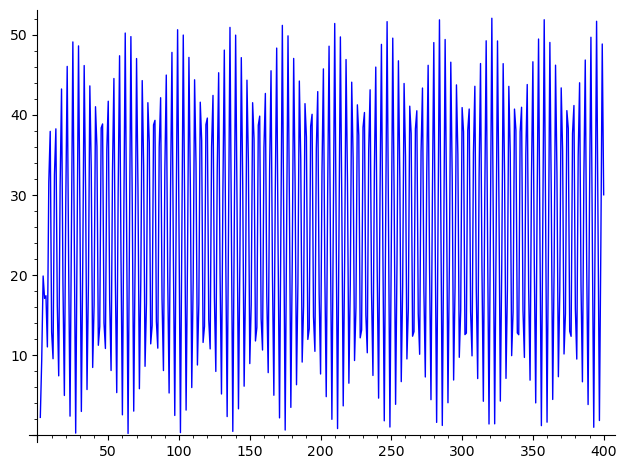

LOGS MINIMUM MODULI


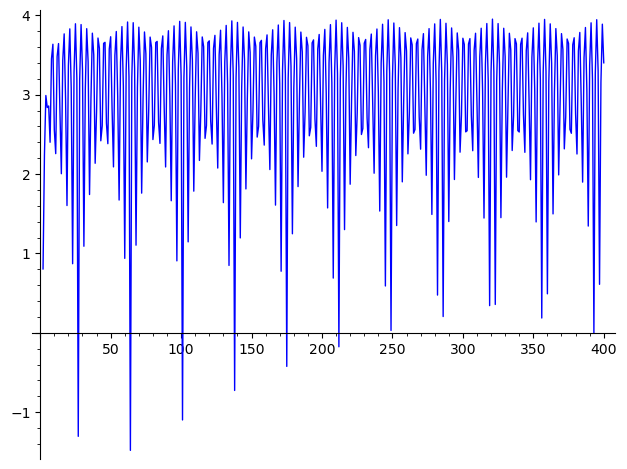

minimum logarithm of minimum modulus: -1.4819234769066430204168644894283?
MAXIMUM MODULI


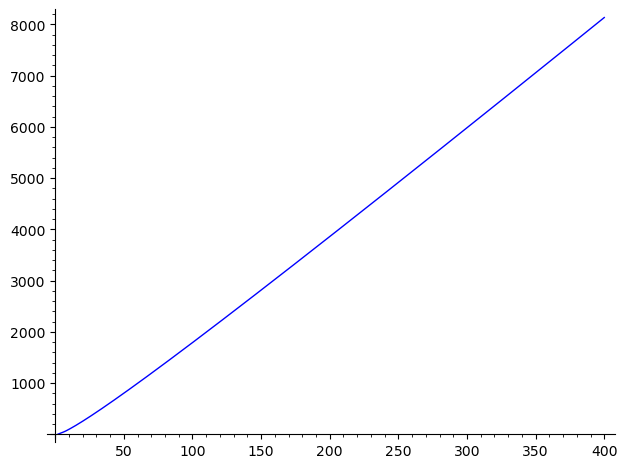

LOGS MAXIMUM MODULI


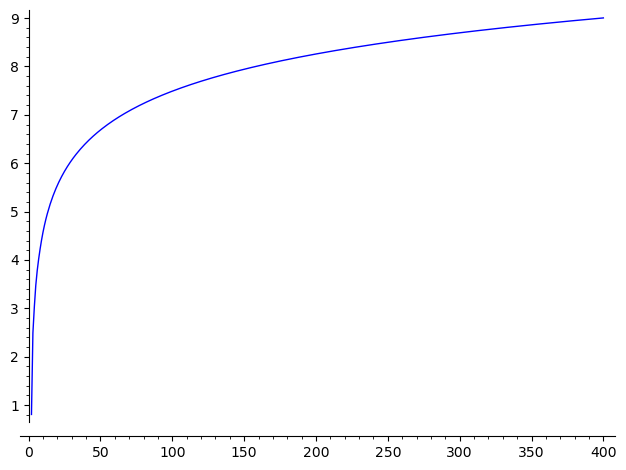

Saving results...
All results saved!
Output files saved to: /Users/barrybrent/data2/
Data range: n = 2 to 400
Number of data points: 399
Min modulus range: 0.227200 to 52.067661
Log min modulus range: -1.481923 to 3.952544

Polynomial trend coefficients: [-2.40901145e-06  1.25494764e-03  2.81962283e+00]
Detrended data std dev: 0.9740

TOP DOMINANT PERIODICITIES (in index n)
Rank   Period       Frequency    Power          
----------------------------------------------------------------------
1            4.11     0.243108       5.40e+04
2            2.06     0.486216       7.63e+03
3            3.69     0.270677       4.62e+03


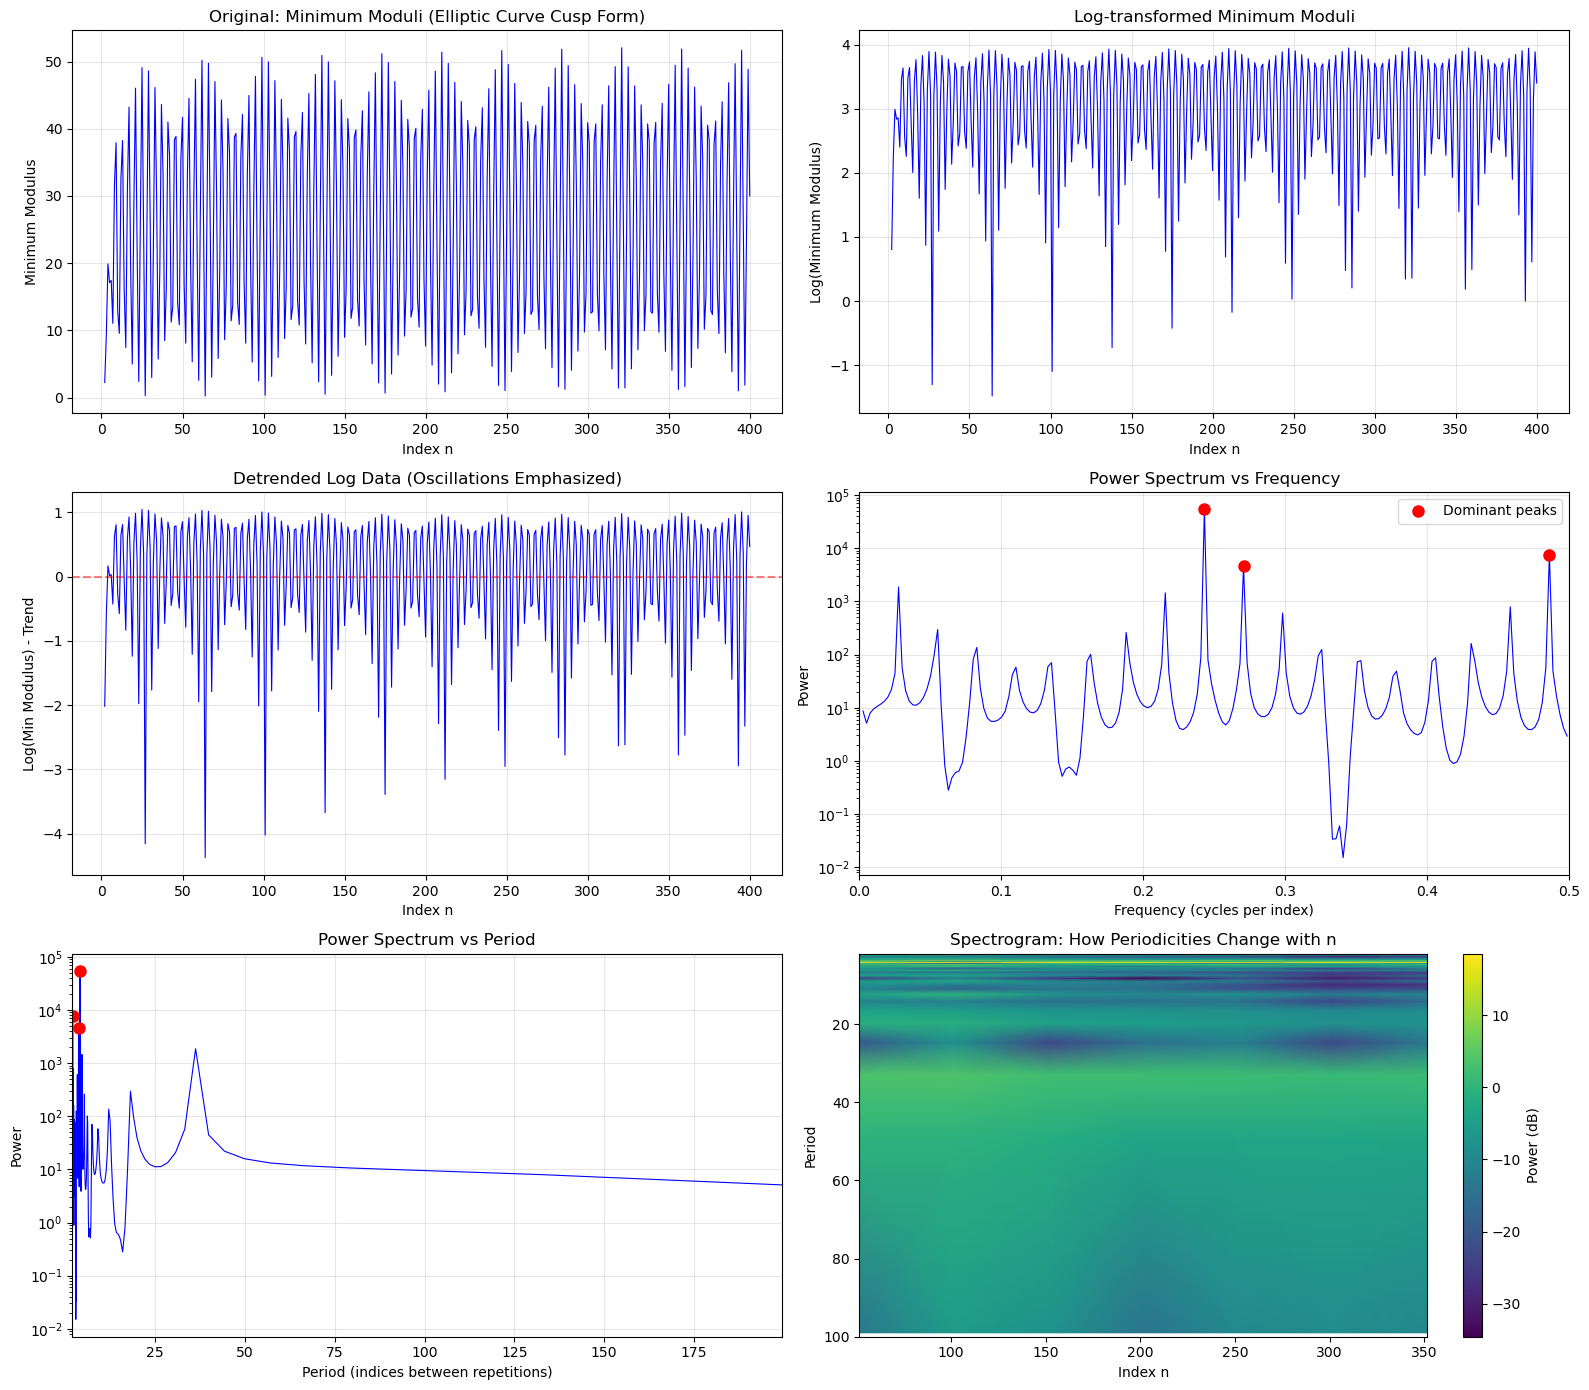


SIGNAL RECONSTRUCTION (using top 5 frequencies)
Component 1: Period = 4.11, Amplitude = 0.0236
Component 2: Period = 2.06, Amplitude = 0.0188
Component 3: Period = 3.69, Amplitude = 0.0206


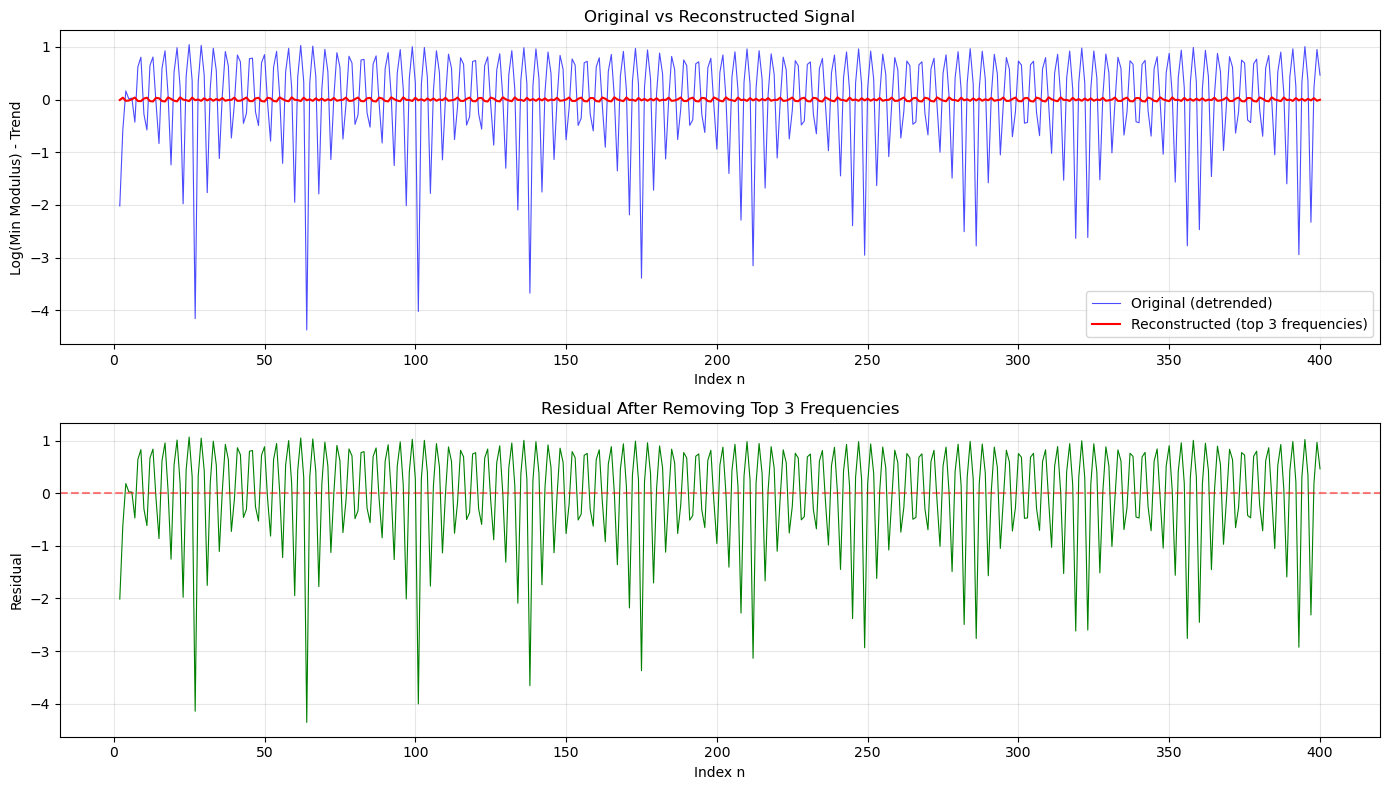


Analysis complete! Examine the plots and frequency table above.


In [2]:
import pickle
from sage.all import sigma, nth_prime, matrix, QQ, ComplexIntervalField, polygen, log, list_plot, flatten, pari


pari.allocatemem(6*10**9) 
print(f"PARI stack size set to: {pari.stacksize() / 1e9:.2f} GB")


_sigma_cache = {}
_nth_prime_cache = {}

def sigma_cached(n):
    if n not in _sigma_cache:
        _sigma_cache[n] = sigma(n)
    return _sigma_cache[n]

def nth_prime_cached(n):
    if n not in _nth_prime_cache:
        _nth_prime_cache[n] = nth_prime(n)
    return _nth_prime_cache[n]

print("Memoization setup complete")


def tau(n):
    def step3(n):
        ans = 0
        n_sq = n * n
        
        
        sigma_vals = [sigma_cached(k) for k in range(1, n)]
        sigma_n_minus_k = [sigma_cached(n - k) for k in range(1, n)]
        
        for k in range(1, n):
            
            k_sq = k * k
            step1_val = 35 * k_sq * k_sq - 52 * k_sq * k * n + 18 * k_sq * n_sq
            
            
            step2_val = sigma_vals[k-1] * sigma_n_minus_k[k-1]
            
            ans += step1_val * step2_val
        
        return 24 * ans
    
    return n**4 * sigma_cached(n) - step3(n)

def h(n):
    
    return tau(nth_prime_cached(n))

print("Functions defined")


print("Computing j_list...")
c = 2 #<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
j_list = [c, 1]

for n in range(2, 401):
    if n % 50 == 0:
        print(f"Progress: n={n}/400")
    
    
    h_vals = [h(n - r) for r in range(1, n)]
    
   
    partial_sum = sum(j_list[r] * h_vals[r-1] for r in range(1, n))
    
    j_n = n * h(n) - partial_sum
    j_list.append(j_n)

print(f"j_list computed with {len(j_list)} elements")


output_path = '/Users/barrybrent/data2/'

with open(output_path + 'run4feb26no6.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile)
    
print(f"j_list saved to {output_path}run27nov25no1.txt")


def P_matrix(lst):
    """Construct P matrix more efficiently"""
    lenlist = len(lst)
    columns = []
    
    
    columns.append(lst)
    
   
    for k in range(1, lenlist):
        column = [0] * (k - 1) + [-k]
        column = flatten(column + [lst])
        column = column[:lenlist]
        columns.append(column)
    
    return matrix(columns).transpose()

print("P_matrix function defined")


precision_bits = 100
CC = ComplexIntervalField(precision_bits)
x = polygen(QQ)

# Pre-allocate lists (NOTE: no matrix_list - saves memory!)
charpol_list = []
roots_list = []
aar_list = []


mins_list = []
log_mins_list = []
maxes_list = []
log_maxes_list = []
dets = []

print("Setup complete for matrix computations")


print("Computing matrices and roots...")
for n in range(2, 401):  # Changed to 401 to match j_list size
    if n % 20 == 0:
        print(f"Progress: n={n}/400")
    
    
    pl = P_matrix(j_list[:n])
    det = pl.det()
    dets.append((n, det))
   
    
    
    cp = pl.charpoly()
    charpol_list.append((n, cp))
    
    
    roots = cp.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    
    
    
    aar = [r.abs() for r in roots]
    aar_list.append((n, aar))
    
    
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))
        
        if minn > 0:
            log_minn = log(minn)
            log_mins_list.append((n, log_minn))
        
        maxx = max(aar)
        maxes_list.append((n, maxx))
        
        if maxx > 0:
            log_maxx = log(maxx)
            log_maxes_list.append((n, log_maxx))

print("Computation complete!")


print("Generating plots...")

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

p = list_plot(log_mins_list, plotjoined=True, axes_labels=['', ''])
print("LOGS MINIMUM MODULI")
p.show()

mml = [pair[1] for pair in log_mins_list]
print("minimum logarithm of minimum modulus:", min(mml))

p = list_plot(maxes_list, plotjoined=True, axes_labels=['', ''])
print("MAXIMUM MODULI")
p.show()

p = list_plot(log_maxes_list, plotjoined=True, axes_labels=['', ''])
print("LOGS MAXIMUM MODULI")
p.show()

  
print("Saving results...")

with open(output_path + 'run4feb26no7.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile)

with open(output_path + 'run4feb26no8.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile)

with open(output_path + 'run4feb26no9.txt', 'wb') as wfile:
    pickle.dump(log_mins_list, wfile)

with open(output_path + 'run4feb26no10.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)

print("All results saved!")
print(f"Output files saved to: {output_path}")

# FOURIER ANALYSIS OF MINIMUM MODULI - Elliptic Curve Cusp Form
# This cell performs spectral analysis on the minimum moduli sequence
# to detect periodicities, dominant frequencies, and oscillatory patterns




import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARE THE DATA - Convert from SageMath to Python/NumPy types
# ==============================================================================

# Extract the data from mins_list and convert to Python floats
# This is crucial because SageMath uses its own numeric types
indices = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
min_moduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)

# Also prepare the log-transformed data
log_min_moduli = np.log(min_moduli)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {len(indices)}")
print(f"Min modulus range: {min_moduli.min():.6f} to {min_moduli.max():.6f}")
print(f"Log min modulus range: {log_min_moduli.min():.6f} to {log_min_moduli.max():.6f}")

# ==============================================================================
# 2. DETRENDING (Important for seeing oscillations)
# ==============================================================================

# For the log data, remove any polynomial trend to focus on oscillations
# We'll try both linear and quadratic detrending

# Linear detrend
log_detrended_linear = signal.detrend(log_min_moduli, type='linear')

# Polynomial detrend (degree 2) - captures parabolic growth
poly_coeffs = np.polyfit(indices, log_min_moduli, deg=2)
poly_trend = np.polyval(poly_coeffs, indices)
log_detrended_poly = log_min_moduli - poly_trend

print(f"\nPolynomial trend coefficients: {poly_coeffs}")
print(f"Detrended data std dev: {np.std(log_detrended_poly):.4f}")

# ==============================================================================
# 3. COMPUTE FOURIER TRANSFORM
# ==============================================================================

# Use FFT on the detrended log data
# The FFT reveals which "frequencies" (periodicities in n) are present

fft_result = np.fft.fft(log_detrended_poly)
fft_frequencies = np.fft.fftfreq(len(indices), d=1.0)  # d=1 means indices are spaced by 1

# Power spectrum (magnitude squared)
power_spectrum = np.abs(fft_result)**2

# Only keep positive frequencies (negative are redundant for real signals)
positive_freq_mask = fft_frequencies > 0
frequencies = fft_frequencies[positive_freq_mask]
power = power_spectrum[positive_freq_mask]

# Convert frequency to period: period = 1/frequency
# (period tells us "spikes repeat every X indices")
periods = 1.0 / frequencies

# ==============================================================================
# 4. IDENTIFY DOMINANT FREQUENCIES
# ==============================================================================

# Find peaks in the power spectrum
# Lower threshold to catch more peaks since we have more data (n up to 400)
peak_indices = signal.find_peaks(power, height=np.max(power)*0.05)[0]  # peaks at least 5% of max
peak_powers = power[peak_indices]
peak_periods = periods[peak_indices]

# Sort by power (strongest first)
sorted_indices = np.argsort(peak_powers)[::-1]
top_peaks = sorted_indices[:min(15, len(sorted_indices))]  # Show top 15

print("\n" + "="*70)
print("TOP DOMINANT PERIODICITIES (in index n)")
print("="*70)
print(f"{'Rank':<6} {'Period':<12} {'Frequency':<12} {'Power':<15}")
print("-"*70)
for rank, idx in enumerate(top_peaks, 1):
    period = peak_periods[idx]
    freq = frequencies[peak_indices[idx]]
    pwr = peak_powers[idx]
    print(f"{rank:<6} {period:>10.2f}   {freq:>10.6f}   {pwr:>12.2e}")

# ==============================================================================
# 5. VISUALIZATIONS
# ==============================================================================

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Plot 5.1: Original data (linear scale)
axes[0, 0].plot(indices, min_moduli, 'b-', linewidth=0.8)
axes[0, 0].set_xlabel('Index n')
axes[0, 0].set_ylabel('Minimum Modulus')
axes[0, 0].set_title('Original: Minimum Moduli (Elliptic Curve Cusp Form)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 5.2: Log scale data
axes[0, 1].plot(indices, log_min_moduli, 'b-', linewidth=0.8)
axes[0, 1].set_xlabel('Index n')
axes[0, 1].set_ylabel('Log(Minimum Modulus)')
axes[0, 1].set_title('Log-transformed Minimum Moduli')
axes[0, 1].grid(True, alpha=0.3)

# Plot 5.3: Detrended data (shows oscillations more clearly)
axes[1, 0].plot(indices, log_detrended_poly, 'b-', linewidth=0.8)
axes[1, 0].set_xlabel('Index n')
axes[1, 0].set_ylabel('Log(Min Modulus) - Trend')
axes[1, 0].set_title('Detrended Log Data (Oscillations Emphasized)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)

# Plot 5.4: Power Spectrum vs Frequency
axes[1, 1].semilogy(frequencies, power, 'b-', linewidth=0.8)
axes[1, 1].semilogy(frequencies[peak_indices[top_peaks]], 
                     peak_powers[top_peaks], 'ro', markersize=8, label='Dominant peaks')
axes[1, 1].set_xlabel('Frequency (cycles per index)')
axes[1, 1].set_ylabel('Power')
axes[1, 1].set_title('Power Spectrum vs Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 0.5)  # Nyquist limit

# Plot 5.5: Power Spectrum vs Period (often more intuitive)
# Only plot periods up to half the data length (longer periods unreliable)
max_period = len(indices) / 2
period_mask = periods <= max_period
axes[2, 0].semilogy(periods[period_mask], power[period_mask], 'b-', linewidth=0.8)
# Mark dominant periods
for idx in top_peaks:
    if peak_periods[idx] <= max_period:
        axes[2, 0].semilogy(peak_periods[idx], peak_powers[idx], 'ro', markersize=8)
axes[2, 0].set_xlabel('Period (indices between repetitions)')
axes[2, 0].set_ylabel('Power')
axes[2, 0].set_title('Power Spectrum vs Period')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(2, max_period)

# Plot 5.6: Spectrogram (time-frequency analysis using Short-Time Fourier Transform)
# This shows if periodicities change over the sequence
window_size = min(128, len(indices)//4)  # adaptive window size, larger for more data
f_spec, t_spec, Sxx = signal.spectrogram(log_detrended_poly, fs=1.0, 
                                          nperseg=window_size, 
                                          noverlap=window_size//2)
# Convert frequency axis to period for easier interpretation
period_spec = 1.0 / (f_spec + 1e-10)  # avoid division by zero
period_spec = period_spec[1:]  # remove DC component
Sxx = Sxx[1:, :]

# Plot with period on y-axis (inverted so small periods at bottom)
im = axes[2, 1].pcolormesh(indices[0] + t_spec, period_spec, 10*np.log10(Sxx + 1e-10),
                           shading='gouraud', cmap='viridis')
axes[2, 1].set_xlabel('Index n')
axes[2, 1].set_ylabel('Period')
axes[2, 1].set_title('Spectrogram: How Periodicities Change with n')
axes[2, 1].set_ylim(2, min(100, max_period))
axes[2, 1].invert_yaxis()  # small periods at bottom
plt.colorbar(im, ax=axes[2, 1], label='Power (dB)')

plt.tight_layout()
plt.show()

# ==============================================================================
# 6. FILTERED SIGNAL (reconstruct using only dominant frequencies)
# ==============================================================================

# Reconstruct signal using only the top 5 dominant frequencies
# This shows what the "pure" oscillatory pattern looks like

print("\n" + "="*70)
print("SIGNAL RECONSTRUCTION (using top 5 frequencies)")
print("="*70)

reconstructed = np.zeros_like(log_detrended_poly)
num_components = min(5, len(top_peaks))
for rank, idx in enumerate(top_peaks[:num_components], 1):  
    freq = frequencies[peak_indices[idx]]
    period = peak_periods[idx]
    # Get amplitude and phase from FFT
    amp = np.abs(fft_result[peak_indices[idx]]) / len(indices)
    phase = np.angle(fft_result[peak_indices[idx]])
    # Reconstruct this component
    component = amp * np.cos(2 * np.pi * freq * indices + phase)
    reconstructed += component
    print(f"Component {rank}: Period = {period:.2f}, Amplitude = {amp:.4f}")

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(indices, log_detrended_poly, 'b-', linewidth=0.8, alpha=0.7, label='Original (detrended)')
axes[0].plot(indices, reconstructed, 'r-', linewidth=1.5, label=f'Reconstructed (top {num_components} frequencies)')
axes[0].set_xlabel('Index n')
axes[0].set_ylabel('Log(Min Modulus) - Trend')
axes[0].set_title('Original vs Reconstructed Signal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual (what's left after removing dominant frequencies)
residual = log_detrended_poly - reconstructed
axes[1].plot(indices, residual, 'g-', linewidth=0.8)
axes[1].set_xlabel('Index n')
axes[1].set_ylabel('Residual')
axes[1].set_title(f'Residual After Removing Top {num_components} Frequencies')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Analysis complete! Examine the plots and frequency table above.")
print("="*70)


Data range: n = 2 to 400
Number of data points: 399
Min modulus range: 0.227200 to 52.067661

SEGMENTATION
  Breakpoints detected: 0
  Segment 1: n = 2 to 400  (399 points)  range [0.23, 52.07]

ANALYSIS: Segment 1  (n = 2 to 400, 399 points)

  Detrending: linear fit (slope = 0.0053)
    Detrended std dev: 14.9282
    Envelope normalization: not needed (dynamic range 1.0x)

    FFT significant peaks: 1
    Rank   Period     Power           Signif.   
    1          4.11     1.17e+07   99%

    Multi-scale periods detected:
         4.0  raw          ACF=0.9678  FUNDAMENTAL
         8.0  MA(5)        ACF=0.8053  integer multiple
        12.0  MA(11)       ACF=0.7085  integer multiple
        21.0  MA(17)       ACF=0.3405  integer multiple
        29.0  MA(25)       ACF=0.2516  integer multiple
        58.0  MA(55)       ACF=0.3093  integer multiple

    Verdict: PERIODIC
    period 4.0, ACF strength 0.9678  (confirmed by FFT)

OVERALL SUMMARY
  Segment 1 (n=2..400): PERIODIC  period=4.

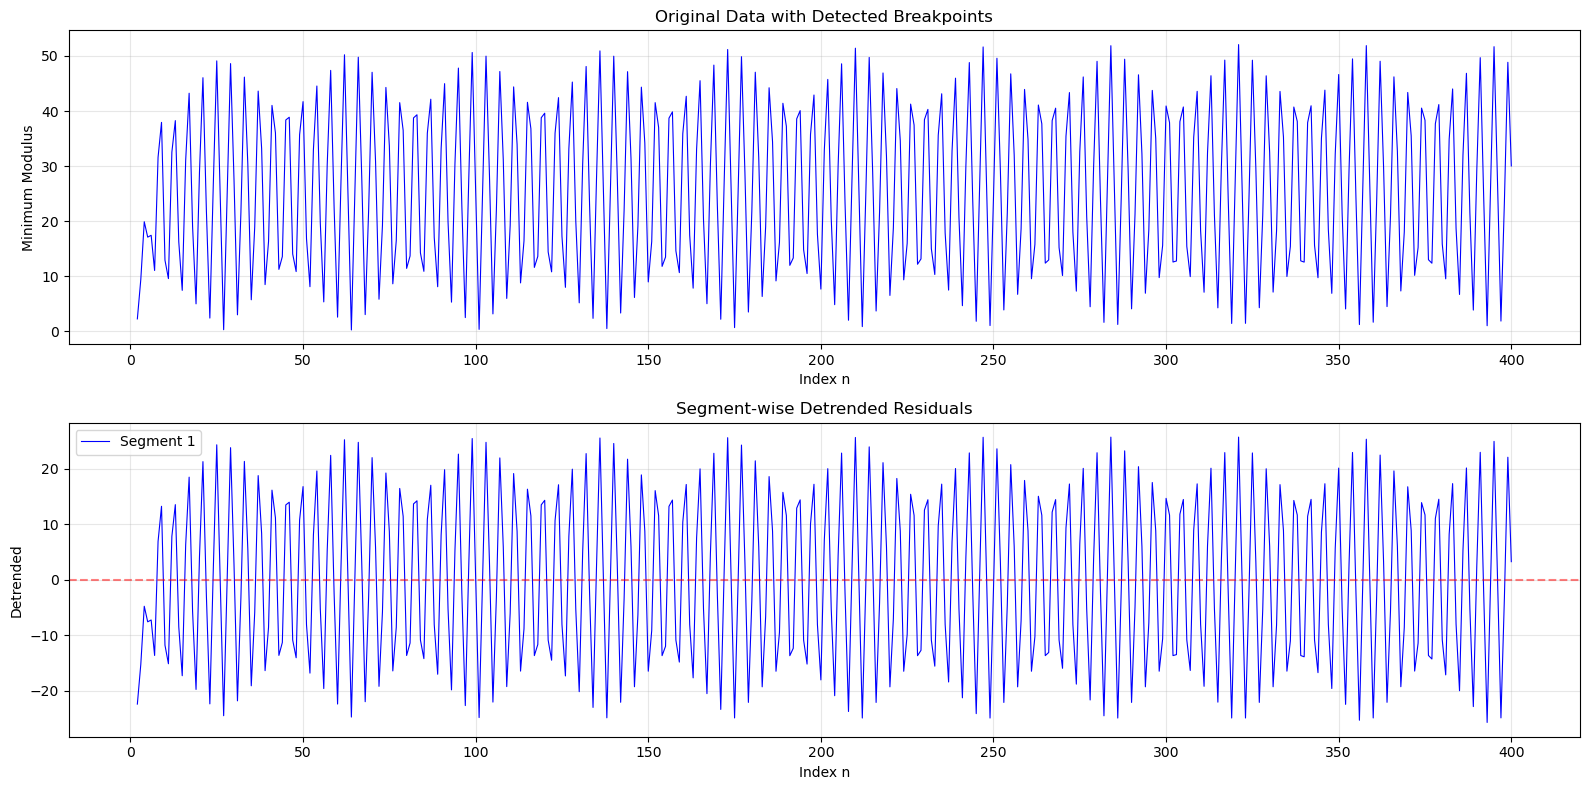

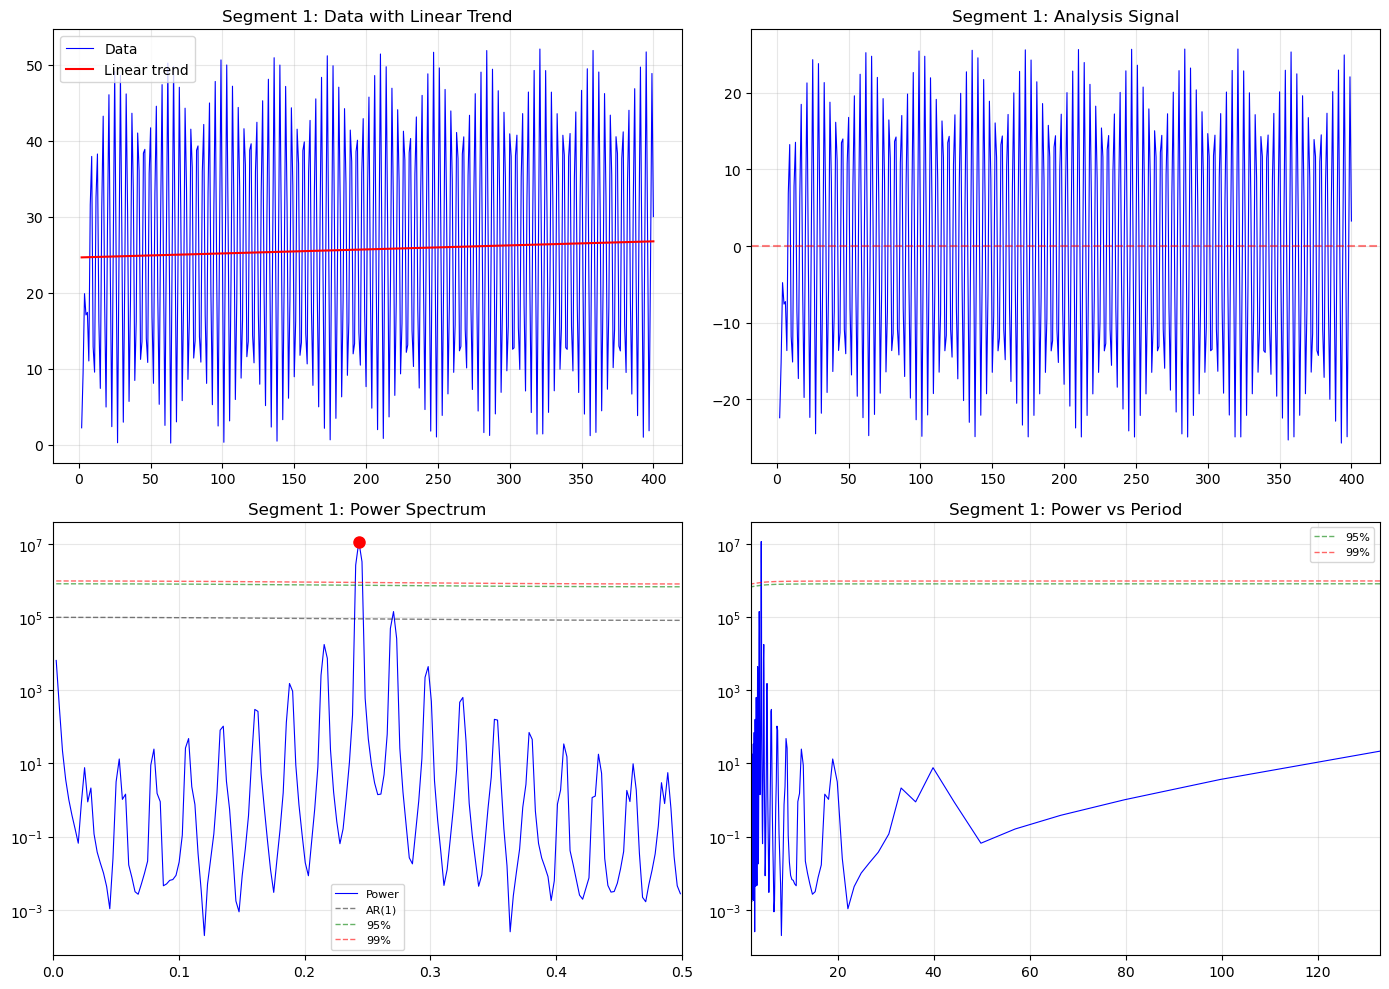


Analysis complete.


In [1]:
import pickle
with open('/Users/barrybrent/data2/run4feb26no10.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile)
# SEGMENTED FOURIER ANALYSIS OF MINIMUM MODULI  (v9.5)
#
# KEY CHANGE: Instead of fitting one curve to the entire dataset, the code
# first detects breakpoints where the data's behavior changes (e.g., from
# a linear ramp to a flat plateau), splits the data into segments at those
# breakpoints, and detrends each segment independently with a simple
# linear fit.  The periodicity analysis then runs on each segment separately.
#
# This avoids the fundamental problem of all previous versions: no single
# polynomial or smoother can cleanly follow a piecewise-linear shape, and
# the residual artifacts from trying corrupt every downstream step.
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. BREAKPOINT DETECTION
# ==============================================================================
# Detect points where the data's local behavior changes qualitatively.
# We use a piecewise-linear model: the data is approximated by straight
# line segments joined at breakpoints.  The algorithm finds the breakpoint
# positions that minimize the total squared error.
#
# We use the 'ruptures' library (Truong, Oudre, Vayatis 2020) with the
# Pelt algorithm, which automatically determines the number of breakpoints.

import ruptures as rpt

# Penalty controls sensitivity: higher = fewer breakpoints, lower = more.
# We calibrate it relative to the data's variance.
penalty_value = np.log(N) * np.var(minmoduli)

algo = rpt.Pelt(model="l2", min_size=max(20, N // 10)).fit(minmoduli)
breakpoints = algo.predict(pen=penalty_value)

# ruptures returns breakpoint indices where each segment ENDS.
# The last entry is always N (end of data).  Convert to segment boundaries.
seg_boundaries = [0] + breakpoints  # e.g. [0, 120, 350]

n_segments = len(seg_boundaries) - 1

print(f"\n{'='*75}")
print(f"SEGMENTATION")
print(f"{'='*75}")
print(f"  Breakpoints detected: {n_segments - 1}")
for i in range(n_segments):
    start_idx = seg_boundaries[i]
    end_idx = seg_boundaries[i+1]
    seg_indices = indices[start_idx:end_idx]
    seg_values = minmoduli[start_idx:end_idx]
    print(f"  Segment {i+1}: n = {int(seg_indices[0])} to {int(seg_indices[-1])}  "
          f"({end_idx - start_idx} points)  "
          f"range [{seg_values.min():.2f}, {seg_values.max():.2f}]")

# ==============================================================================
# 3. ANALYZE EACH SEGMENT
# ==============================================================================

def analyze_segment(seg_indices, seg_values, seg_label):
    """Run the full periodicity analysis on one segment."""
    n = len(seg_indices)

    if n < 10:
        print(f"\n  Segment too short ({n} points) for analysis.")
        return None

    max_credible_period = n / 3.0

    # --- Linear detrend (appropriate for each piecewise-linear segment) ---
    coeffs = np.polyfit(seg_indices, seg_values, deg=1)
    trend = np.polyval(coeffs, seg_indices)
    detrended = seg_values - trend
    slope = coeffs[0]

    print(f"\n  Detrending: linear fit (slope = {slope:.4f})")
    print(f"    Detrended std dev: {np.std(detrended):.4f}")

    # --- Envelope normalization (if needed) ---
    abs_det = np.abs(detrended)
    env_win = max(5, min(n // 10, n // 3))
    if env_win % 2 == 0:
        env_win += 1
    env_win = min(env_win, n - 1)
    if env_win % 2 == 0:
        env_win -= 1
    if env_win < 5:
        env_win = 5
    if env_win >= n:
        envelope_applied = False
        analysis_signal = detrended
    else:
        envelope = signal.savgol_filter(abs_det, window_length=env_win,
                                        polyorder=min(2, env_win - 1))
        env_floor = np.percentile(abs_det[abs_det > 0], 5) if np.any(abs_det > 0) else 1.0
        envelope = np.maximum(envelope, env_floor)

        env_p10 = np.percentile(envelope, 10)
        env_p90 = np.percentile(envelope, 90)
        envelope_ratio = env_p90 / env_p10 if env_p10 > 0 else 1.0

        if envelope_ratio > 3.0:
            analysis_signal = detrended / envelope
            envelope_applied = True
            print(f"    Envelope normalization: APPLIED (dynamic range {envelope_ratio:.1f}x)")
        else:
            analysis_signal = detrended
            envelope_applied = False
            print(f"    Envelope normalization: not needed (dynamic range {envelope_ratio:.1f}x)")

    # --- Windowed FFT ---
    window = np.hanning(n)
    windowed = analysis_signal * window
    window_power_correction = n / np.sum(window**2)

    fft_result     = np.fft.fft(windowed)
    fft_freqs      = np.fft.fftfreq(n, d=1.0)
    power_spectrum = np.abs(fft_result)**2 * window_power_correction

    pos = fft_freqs > 0
    frequencies = fft_freqs[pos]
    power       = power_spectrum[pos]
    periods     = 1.0 / frequencies

    # --- AR(1) significance with Bonferroni correction ---
    rho = np.corrcoef(analysis_signal[:-1], analysis_signal[1:])[0, 1]
    variance = np.var(analysis_signal)

    ar1_power = (variance * (1 - rho**2)) / (
        1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
    )
    ar1_power *= np.mean(power) / np.mean(ar1_power)

    credible_mask = periods <= max_credible_period
    n_tests = int(np.sum(credible_mask))
    if n_tests < 1:
        n_tests = 1

    alpha_95_corrected = 1.0 - (0.05 / n_tests)
    alpha_99_corrected = 1.0 - (0.01 / n_tests)

    chi2_95 = stats.chi2.ppf(alpha_95_corrected, df=2) / 2.0
    chi2_99 = stats.chi2.ppf(alpha_99_corrected, df=2) / 2.0
    conf_95 = ar1_power * chi2_95
    conf_99 = ar1_power * chi2_99

    # --- Significant FFT peaks ---
    peak_idx = signal.find_peaks(power, height=0)[0]
    significant_peaks = []
    for pi in peak_idx:
        if not credible_mask[pi]:
            continue
        if power[pi] > conf_99[pi]:
            significant_peaks.append((pi, '99%'))
        elif power[pi] > conf_95[pi]:
            significant_peaks.append((pi, '95%'))

    significant_peaks.sort(key=lambda x: power[x[0]], reverse=True)

    # --- Multi-scale ACF fundamental detection ---
    detected_periods = []
    smooth_widths = [1]
    w = 3
    while w < max_credible_period / 2:
        smooth_widths.append(w)
        w = max(w + 2, int(w * 1.5))
        if w % 2 == 0:
            w += 1

    for sw in smooth_widths:
        if sw == 1:
            smoothed = analysis_signal.copy()
            scale_label = "raw"
        else:
            kernel = np.ones(sw) / sw
            smoothed = np.convolve(analysis_signal, kernel, mode='same')
            scale_label = f"MA({sw})"

        sm_centered = smoothed - smoothed.mean()
        acf_sm = np.correlate(sm_centered, sm_centered, 'full')
        acf_sm = acf_sm[n-1:]
        if acf_sm[0] > 0:
            acf_sm = acf_sm / acf_sm[0]
        else:
            continue

        search_start = max(2, sw + 1) if sw > 1 else 2
        search_end = min(int(max_credible_period), len(acf_sm) - 1)
        if search_start >= search_end:
            continue

        slice_begin = max(0, search_start - 1)
        acf_slice = acf_sm[slice_begin:search_end+1]
        peaks_in_slice, props = signal.find_peaks(acf_slice, height=0.1)

        boundary_offset = search_start - slice_begin
        if (boundary_offset not in peaks_in_slice and
                search_start < len(acf_sm) - 1 and search_start > 0):
            val = acf_sm[search_start]
            left = acf_sm[search_start - 1]
            right = acf_sm[search_start + 1]
            if val > left and val > right and val > 0.1:
                peaks_in_slice = np.concatenate(([boundary_offset], peaks_in_slice))

        if len(peaks_in_slice) > 0:
            true_lags = peaks_in_slice + slice_begin
            true_lags = true_lags[true_lags >= search_start]
            if len(true_lags) > 0:
                lag = int(true_lags[0])
                strength = acf_sm[lag]
                is_new = True
                for (prev_p, _, _) in detected_periods:
                    if abs(lag - prev_p) / max(lag, prev_p) < 0.15:
                        is_new = False
                        break
                if is_new:
                    detected_periods.append((float(lag), scale_label, float(strength)))

    detected_periods.sort(key=lambda x: x[0])

    fund_period = None
    fund_method = None
    fund_strength = None
    sub_periods = []
    best_fund_idx = 0

    if detected_periods:
        best_explained = 0
        for i, (cand_p, cand_label, cand_str) in enumerate(detected_periods):
            if cand_p < 2:
                continue
            n_explained = 0
            for j, (other_p, _, _) in enumerate(detected_periods):
                if j == i:
                    n_explained += 1
                    continue
                ratio = other_p / cand_p
                nearest = round(ratio)
                if nearest >= 1 and abs(ratio - nearest) / max(nearest, 1) < 0.15:
                    n_explained += 1
            if n_explained > best_explained or (
                    n_explained == best_explained and
                    cand_str > detected_periods[best_fund_idx][2]):
                best_explained = n_explained
                best_fund_idx = i

        fund_period = detected_periods[best_fund_idx][0]
        fund_method = f"multi-scale ACF ({detected_periods[best_fund_idx][1]})"
        fund_strength = detected_periods[best_fund_idx][2]
        sub_periods = [dp for k, dp in enumerate(detected_periods) if k != best_fund_idx]
        sub_periods.sort(key=lambda x: x[0], reverse=True)

    # --- Report ---
    has_fft_evidence = len(significant_peaks) > 0
    has_acf_evidence = fund_period is not None and fund_strength > 0.5

    print(f"\n    FFT significant peaks: {len(significant_peaks)}")
    if significant_peaks:
        print(f"    {'Rank':<6} {'Period':<10} {'Power':<15} {'Signif.':<10}")
        for rank, (pi, level) in enumerate(significant_peaks[:10], 1):
            print(f"    {rank:<6} {periods[pi]:>8.2f} {power[pi]:>12.2e}   {level}")

    if detected_periods:
        print(f"\n    Multi-scale periods detected:")
        for i, (p, label, strength) in enumerate(detected_periods):
            role = "FUNDAMENTAL" if i == best_fund_idx else "integer multiple"
            print(f"      {p:>6.1f}  {label:<12} ACF={strength:.4f}  {role}")

    # --- Verdict ---
    # Binary: PERIODIC or NOT PERIODIC.
    # PERIODIC requires ACF strength > 0.5.  The FFT result is noted when
    # it agrees but is never sufficient on its own ‚Äî a single spectral peak
    # can clear the Bonferroni threshold in a noisy segment by chance, and
    # moderate ACF values (0.2‚Äì0.5) can arise from short-range noise
    # correlation rather than genuine periodicity.
    if has_acf_evidence:
        verdict = "PERIODIC"
        verdict_detail = f"period {fund_period:.1f}, ACF strength {fund_strength:.4f}"
        if has_fft_evidence:
            verdict_detail += "  (confirmed by FFT)"
    else:
        verdict = "NOT PERIODIC"
        verdict_detail = ""

    print(f"\n    Verdict: {verdict}")
    if verdict_detail:
        print(f"    {verdict_detail}")

    return {
        'verdict': verdict,
        'fund_period': fund_period,
        'fund_strength': fund_strength,
        'significant_peaks': significant_peaks,
        'seg_indices': seg_indices,
        'seg_values': seg_values,
        'trend': trend,
        'detrended': detrended,
        'analysis_signal': analysis_signal,
        'frequencies': frequencies,
        'power': power,
        'periods': periods,
        'ar1_power': ar1_power,
        'conf_95': conf_95,
        'conf_99': conf_99,
    }

# ==============================================================================
# RUN ANALYSIS ON EACH SEGMENT
# ==============================================================================

results = []
for i in range(n_segments):
    start_idx = seg_boundaries[i]
    end_idx = seg_boundaries[i+1]
    seg_idx = indices[start_idx:end_idx]
    seg_val = minmoduli[start_idx:end_idx]
    label = f"Segment {i+1}"

    print(f"\n{'='*75}")
    print(f"ANALYSIS: {label}  (n = {int(seg_idx[0])} to {int(seg_idx[-1])}, "
          f"{len(seg_idx)} points)")
    print(f"{'='*75}")

    result = analyze_segment(seg_idx, seg_val, label)
    results.append(result)

# ==============================================================================
# OVERALL SUMMARY
# ==============================================================================
print(f"\n{'='*75}")
print(f"OVERALL SUMMARY")
print(f"{'='*75}")
for i in range(n_segments):
    start_idx = seg_boundaries[i]
    end_idx = seg_boundaries[i+1]
    seg_idx = indices[start_idx:end_idx]
    r = results[i]
    if r is not None:
        print(f"  Segment {i+1} (n={int(seg_idx[0])}..{int(seg_idx[-1])}): {r['verdict']}", end="")
        if r['fund_period'] is not None:
            print(f"  period={r['fund_period']:.1f}  ACF={r['fund_strength']:.4f}", end="")
        print()
    else:
        print(f"  Segment {i+1}: too short")

# ==============================================================================
# VISUALIZATIONS
# ==============================================================================

# --- Overview plot: original data with breakpoints ---
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(indices, minmoduli, 'b-', linewidth=0.8)
for bp in seg_boundaries[1:-1]:
    axes[0].axvline(x=indices[bp] if bp < N else indices[-1],
                    color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].set_xlabel('Index n')
axes[0].set_ylabel('Minimum Modulus')
axes[0].set_title('Original Data with Detected Breakpoints')
axes[0].grid(True, alpha=0.3)

# Detrended segments stitched together for display
colors = ['blue', 'green', 'purple', 'orange', 'brown']
for i, r in enumerate(results):
    if r is not None:
        c = colors[i % len(colors)]
        axes[1].plot(r['seg_indices'], r['detrended'], '-', color=c,
                     linewidth=0.8, label=f'Segment {i+1}')
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Index n')
axes[1].set_ylabel('Detrended')
axes[1].set_title('Segment-wise Detrended Residuals')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Per-segment detail plots ---
for i, r in enumerate(results):
    if r is None:
        continue

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    seg_idx = r['seg_indices']

    # Original segment with linear trend
    axes[0, 0].plot(seg_idx, r['seg_values'], 'b-', linewidth=0.8, label='Data')
    axes[0, 0].plot(seg_idx, r['trend'], 'r-', linewidth=1.5, label='Linear trend')
    axes[0, 0].set_title(f'Segment {i+1}: Data with Linear Trend')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Analysis signal
    axes[0, 1].plot(seg_idx, r['analysis_signal'], 'b-', linewidth=0.8)
    axes[0, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[0, 1].set_title(f'Segment {i+1}: Analysis Signal')
    axes[0, 1].grid(True, alpha=0.3)

    # Power spectrum
    freq = r['frequencies']
    pwr = r['power']
    axes[1, 0].semilogy(freq, pwr, 'b-', linewidth=0.8, label='Power')
    axes[1, 0].semilogy(freq, r['ar1_power'], 'k--', linewidth=1,
                        alpha=0.5, label='AR(1)')
    axes[1, 0].semilogy(freq, r['conf_95'], 'g--', linewidth=1,
                        alpha=0.6, label='95%')
    axes[1, 0].semilogy(freq, r['conf_99'], 'r--', linewidth=1,
                        alpha=0.6, label='99%')
    for pi, level in r['significant_peaks']:
        color = 'red' if level == '99%' else 'orange'
        axes[1, 0].semilogy(freq[pi], pwr[pi], 'o', color=color, markersize=8)
    axes[1, 0].set_title(f'Segment {i+1}: Power Spectrum')
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(0, 0.5)

    # Power spectrum vs period
    periods = r['periods']
    n_seg = len(seg_idx)
    max_p = n_seg / 3.0
    pmask = (periods <= max_p) & (periods >= 2)
    if np.any(pmask):
        axes[1, 1].semilogy(periods[pmask], pwr[pmask], 'b-', linewidth=0.8)
        axes[1, 1].semilogy(periods[pmask], r['conf_95'][pmask], 'g--',
                            linewidth=1, alpha=0.6, label='95%')
        axes[1, 1].semilogy(periods[pmask], r['conf_99'][pmask], 'r--',
                            linewidth=1, alpha=0.6, label='99%')
        axes[1, 1].set_xlim(2, max_p)
    axes[1, 1].set_title(f'Segment {i+1}: Power vs Period')
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)
